In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
%%html
<div style="
    background: linear-gradient(45deg, #0f2027, #203a43, #2c5364);
    padding: 30px;
    border-radius: 15px;
    text-align: center;
">
    <span style="
        font-family: Verdana;
        font-size: 38px;
        font-weight: bold;
        color: white;
        letter-spacing: 2px;
    ">🧠 GAN — Fashion MNIST</span>
    <br><br>
    <span style="color: #a8d8ea; font-size: 16px; font-family: Verdana;">
        Generator &nbsp;•&nbsp; Discriminator &nbsp;•&nbsp; BCELoss &nbsp;•&nbsp; PyTorch
    </span>
    <br><br>
    <span style="color: #cccccc; font-size: 13px;">
        Image Generation &nbsp;|&nbsp; Adversarial Training &nbsp;|&nbsp; Deep Learning
    </span>
</div>

## About

### 🧑‍💻 Mirjalol Eshmurodov
**Deep Learning Engineer**

| | |
|---|---|
| 📌 Tools | Python, PyTorch, torchvision, Matplotlib |
| 📅 Dataset | Fashion MNIST — 60,000 clothing images |
| 🎯 Goal | Generate new clothing images using GAN |

In [3]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center; margin-top: 10px;">
  <span style="font-family: Verdana; color: white;
      font-size: 24px; font-weight: bold;">
    1. Imports & Data Loading 📦
  </span>
</div>

In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

In [5]:
torch.manual_seed(0)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

In [6]:
train_set = torchvision.datasets.FashionMNIST(
    root=".",
    train =True,
    download = True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


In [7]:
batch_size=32
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle =True)

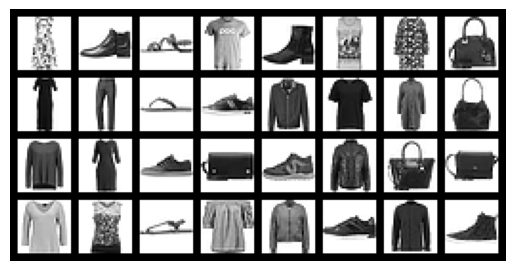

In [8]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

images, labels = next(iter(train_loader))

grid = make_grid(0.5-images/2,8,4)
plt.imshow(grid.numpy().transpose((1,2,0)),
          cmap ='gray_r')
plt.axis("off")
plt.show()

### 💡 Key Insights — Data Loading

- **60,000** training images — 10 clothing categories
- Each image is **28×28 pixels**, grayscale format
- Normalized to `[-1, 1]` range — optimal for GAN training
- `manual_seed(0)` ensures reproducibility

In [9]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center; margin-top: 10px;">
  <span style="font-family: Verdana; color: white;
      font-size: 24px; font-weight: bold;">
    2. Model Architecture 🏗️
  </span>
</div>

In [10]:
import torch 
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

#the discriminator
D = nn.Sequential(
    nn.Linear(784,1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024,512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512,256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256,1),
    nn.Sigmoid()).to(device)

In [11]:
G = nn.Sequential(
    nn.Linear(100, 256),
    nn.ReLU(),
    nn.Linear(256,512),
    nn.ReLU(),
    nn.Linear(512, 1024),
    nn.ReLU(),
    nn.Linear(1024, 784),
    nn.Tanh()).to(device)

### 💡 Key Insights — Architecture

| Model | Input | Output | Role |
|-------|-------|--------|------|
| **Discriminator (D)** | 784 (28×28) | 1 (probability) | Classifies real vs. fake |
| **Generator (G)** | 100 (noise) | 784 (28×28) | Generates new images |

- **Dropout(0.3)** — prevents D from overfitting
- **Tanh** — normalizes G output to `[-1, 1]`
- **Sigmoid** — converts D output to `[0, 1]` probability

In [12]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center; margin-top: 10px;">
  <span style="font-family: Verdana; color: white;
      font-size: 24px; font-weight: bold;">
    3. Loss & Optimizer ⚙️
  </span>
</div>

In [13]:
loss_fn = nn.BCELoss()
lr = 0.0001
optimD = torch.optim.Adam(D.parameters(),lr=lr)
optimG = torch.optim.Adam(G.parameters(), lr=lr)

### 💡 Key Insights — Loss & Optimizer

- **BCELoss** — Binary Cross Entropy: measures how well D distinguishes real from fake
- **Adam (lr=0.0001)** — adaptive optimizer; low learning rate ensures stable GAN training
- Both G and D have **separate optimizers** — they compete and update independently

In [14]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center; margin-top: 10px;">
  <span style="font-family: Verdana; color: white;
      font-size: 24px; font-weight: bold;">
    4. Training Functions 🏋️
  </span>
</div>

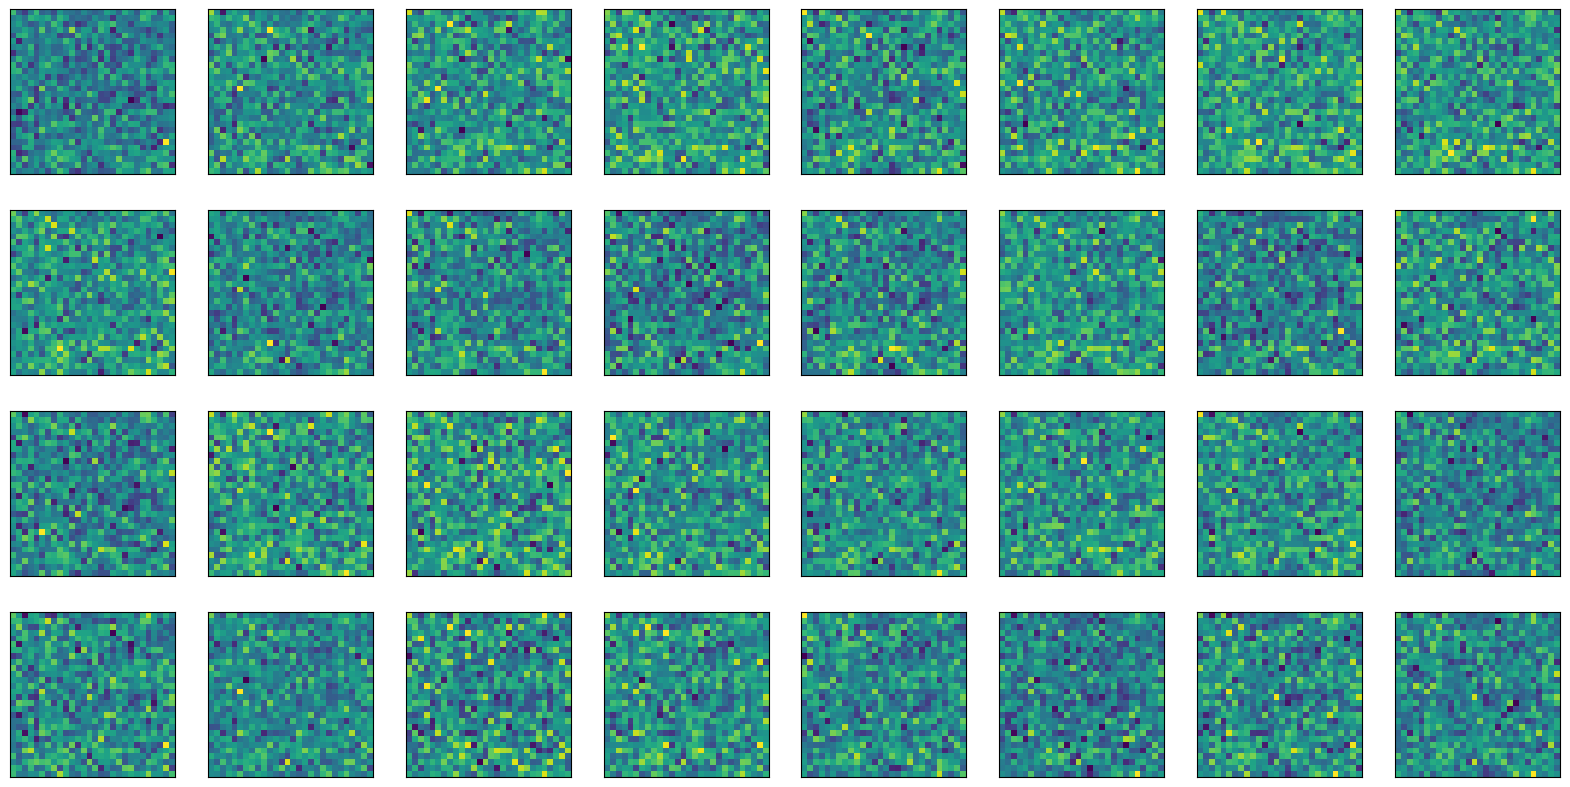

In [15]:
import matplotlib.pyplot as plt

def see_output():
    noise = torch.randn(32,100).to(device)
    fake_samples = G(noise).cpu().detach()
    plt.figure(dpi=100, figsize=(20,10))
    for i in range(32):
        ax = plt.subplot(4,8,i+1)
        img = (fake_samples[i]/2+0.5).reshape(28,28)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
    plt.show()
see_output()

In [16]:
real_labels = torch.ones((batch_size, 1)).to(device)
fake_labels = torch.zeros((batch_size, 1)).to(device)

In [17]:
def train_D_on_real(real_samples):
    r= real_samples.reshape(-1, 28*28).to(device)
    out_D = D(r)
    labels = torch.ones((r.shape[0], 1)).to(device)
    loss_D = loss_fn(out_D, labels)
    optimD.zero_grad()
    loss_D.backward()
    optimD.step()
    return loss_D

In [18]:
def train_D_on_feke():
    noise = torch.randn(batch_size, 100).to(device)
    generated_data = G(noise)
    preds = D(generated_data)
    loss_D=loss_fn(preds, fake_labels)
    optimD.zero_grad()
    loss_D.backward()
    optimD.step()
    return loss_D

In [19]:
def train_G():
    noise = torch.randn(batch_size, 100).to(device)
    generated_data = G(noise)
    preds = D(generated_data)
    loss_G = loss_fn(preds, real_labels)
    optimG.zero_grad()
    loss_G.backward()
    optimG.step()
    return loss_G

### 💡 Key Insights — Training Functions

| Function | What it does |
|----------|--------------|
| `train_D_on_real` | Trains D to output **1** for real images |
| `train_D_on_feke` | Trains D to output **0** for generated images |
| `train_G` | Trains G to fool D — makes D output **1** for fake images |
| `see_output` | Visualizes 32 generated images at current training state |

In [20]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center; margin-top: 10px;">
  <span style="font-family: Verdana; color: white;
      font-size: 24px; font-weight: bold;">
    5. Training Loop 🔄
  </span>
</div>

EPOCH: 10, DLOSS:0.7488023638725281, GLOSS: 1.97576904296875


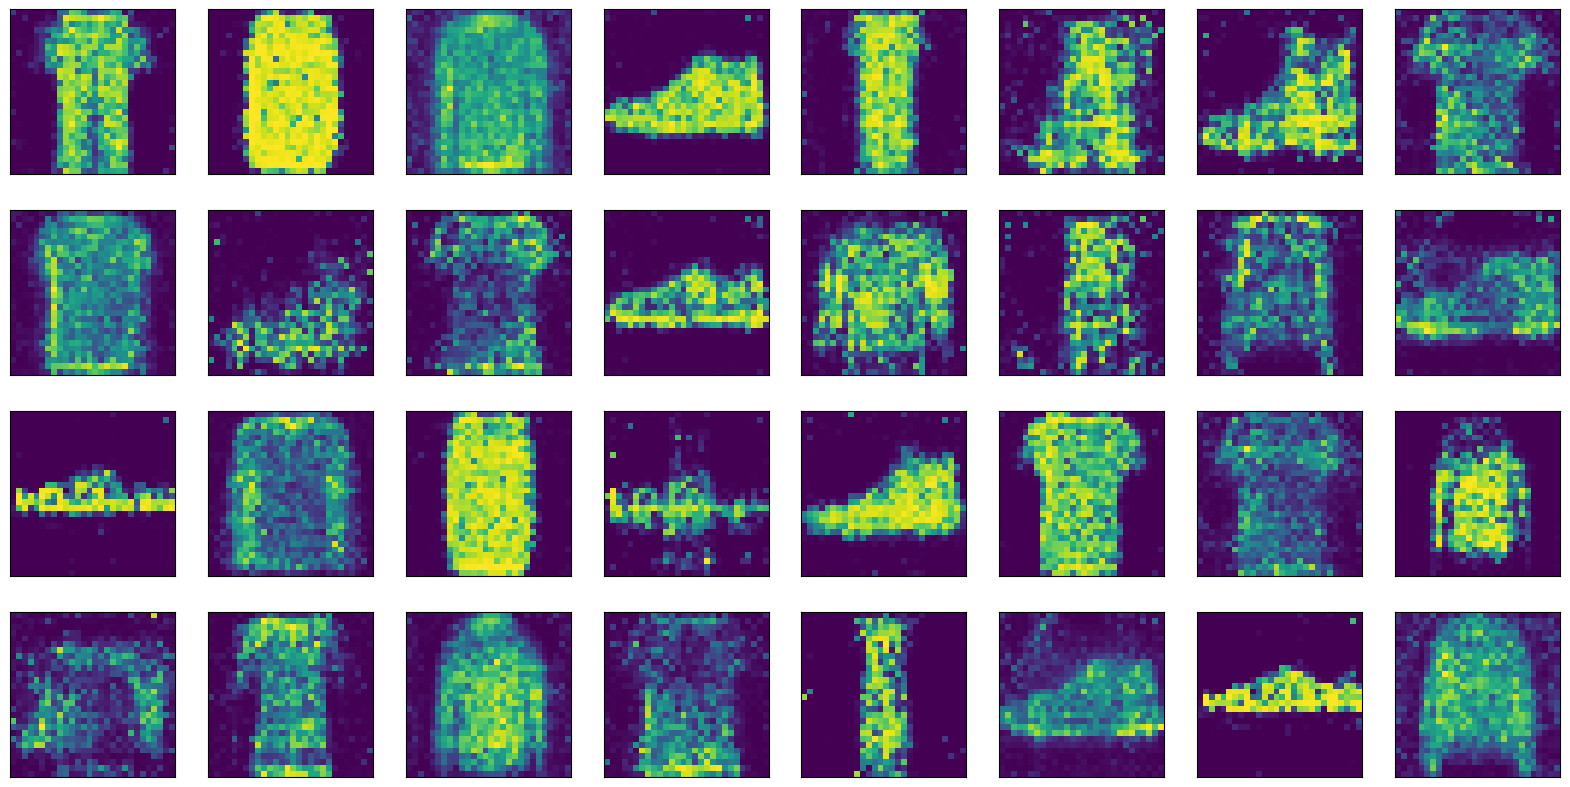

EPOCH: 20, DLOSS:1.0604280233383179, GLOSS: 1.197308897972107


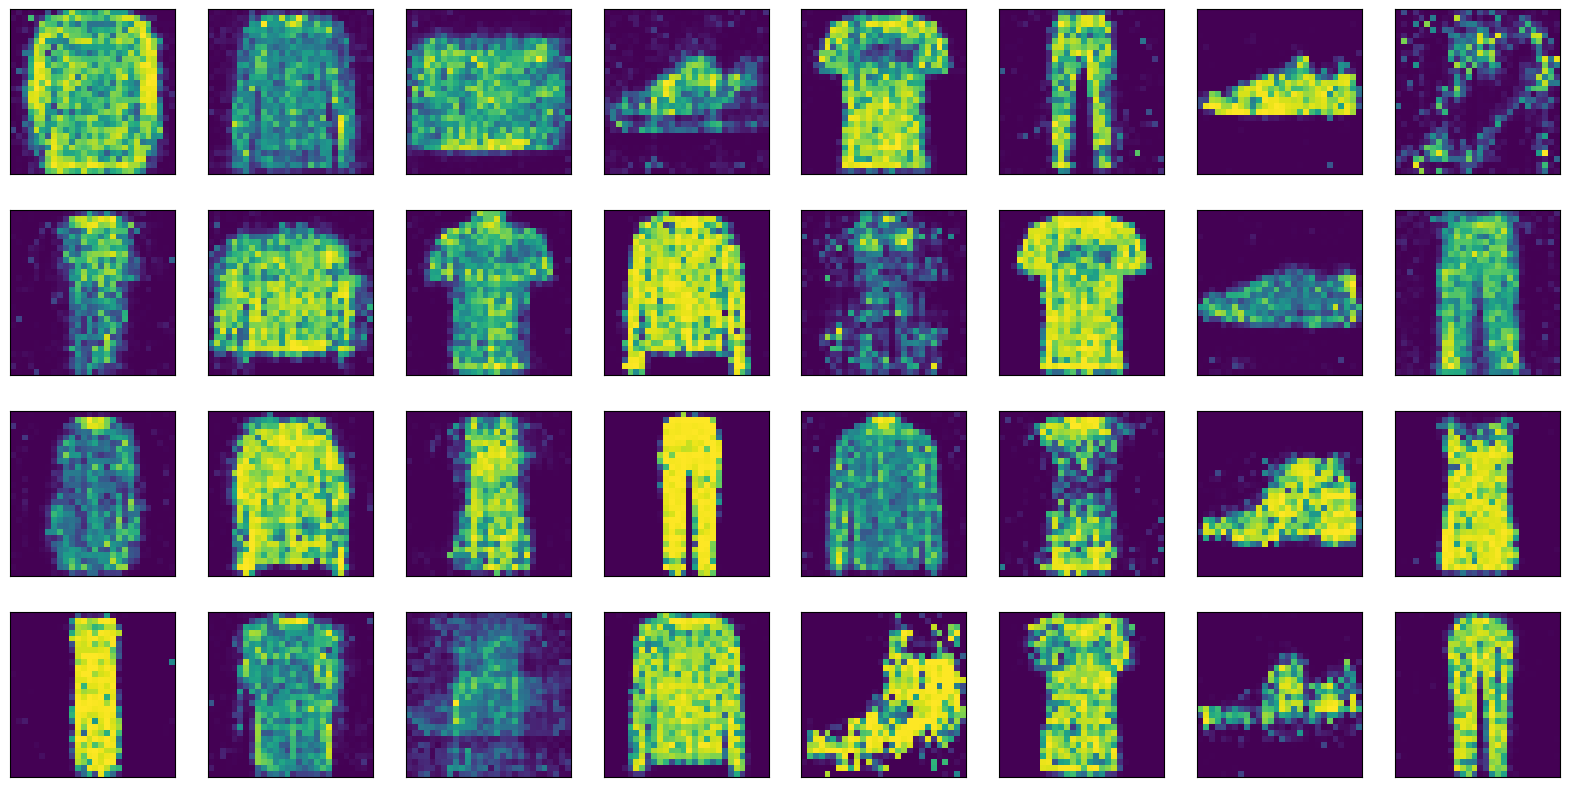

EPOCH: 30, DLOSS:1.1601227521896362, GLOSS: 1.017875075340271


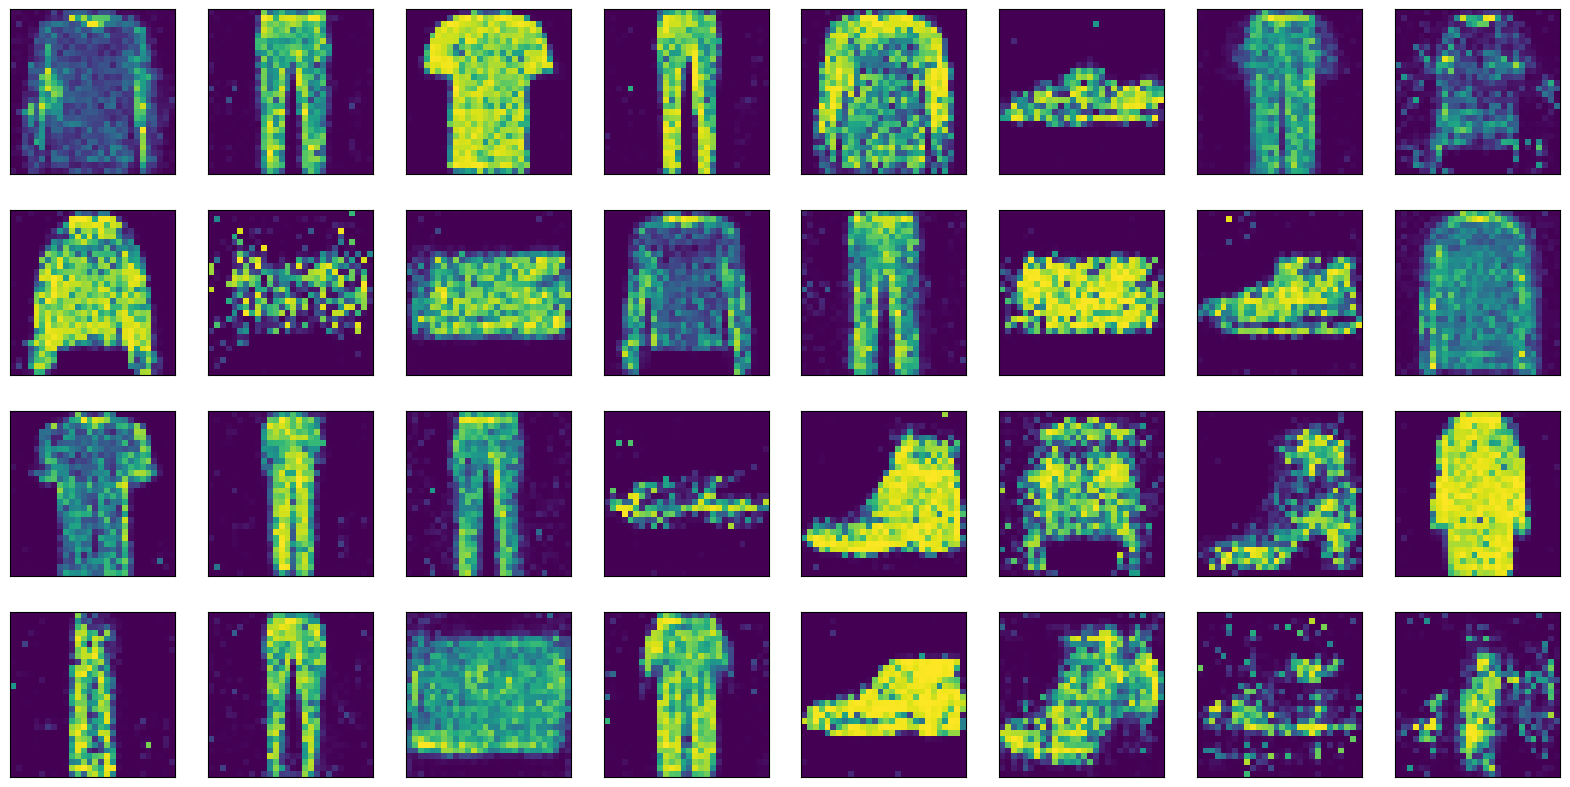

In [21]:
for i in range(30):
    gloss=0
    dloss=0
    for n, (real_samples,_) in enumerate(train_loader):
        loss_D = train_D_on_real(real_samples)
        dloss+=loss_D
        loss_D = train_D_on_feke()
        dloss+=loss_D
        loss_G = train_G()
        gloss+=loss_G
    gloss=gloss/n
    dloss=dloss/n
    if i %10 ==9:
        print(f"EPOCH: {i+1}, DLOSS:{dloss}, GLOSS: {gloss}")
        see_output()

### 💡 Key Insights — Training Loop

- **50 epochs** — full adversarial training cycle
- Each epoch: D trains on real → D trains on fake → G tries to fool D
- Results are printed and visualized every **10 epochs**
- As training progresses, generated images become more realistic

In [22]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center; margin-top: 10px;">
  <span style="font-family: Verdana; color: white;
      font-size: 24px; font-weight: bold;">
    6. Conclusion 🎯
  </span>
</div>

### 📌 Summary

This notebook trained a **GAN** on the **Fashion MNIST** dataset to generate new clothing images from random noise.

---

### 🔍 Key Findings

| Component | Architecture | Role |
|-----------|-------------|------|
| **Generator** | Linear(100→256→512→1024→784) + Tanh | Generates images from noise |
| **Discriminator** | Linear(784→1024→512→256→1) + Sigmoid | Classifies real vs. fake |
| **Loss** | BCELoss | Binary classification |
| **Optimizer** | Adam (lr=0.0001) | Gradient descent |


---

### 💡 Next Steps
- **DCGAN** — Use convolutional layers for higher image quality
- **Conditional GAN** — Generate a specific clothing category on demand
- **WGAN** — Improve training stability with Wasserstein loss

In [23]:
%%html
<div style="
    background: linear-gradient(45deg, #0f2027, #203a43, #2c5364);
    padding: 20px;
    border-radius: 15px;
    text-align: center;
    margin-top: 20px;
">
    <span style="
        font-family: Verdana;
        font-size: 18px;
        color: white;
    ">⭐ If you found this helpful, please upvote! ⭐</span>
    <br><br>
    <span style="color: #aaaaaa; font-size: 13px;">
        Made with Python & PyTorch
    </span>
</div>